<a href="https://colab.research.google.com/github/Abiy-Alemu/CV-Lab1-5/blob/main/CV_Lab_2_Exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Digital Image Processing – Chapter 2: Suggested Exercises
**Addis Ababa University | Master's in Artificial Intelligence**

This notebook covers the three suggested exercises from Chapter 2: *Color Science and Point Operations*.

---

Image shape : (400, 600, 3)
Dtype       : uint8
Value range : [0, 255]


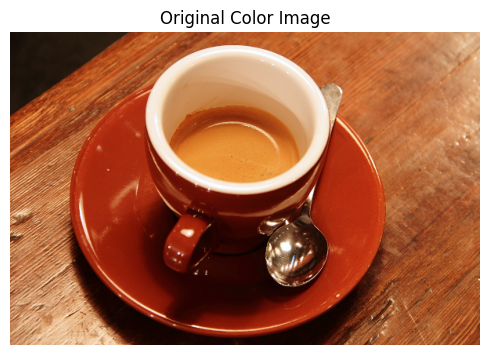

In [8]:
# ── Core imports ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import ipywidgets as widgets
from IPython.display import display

# Load the sample image (peppers)
# Using a built-in sample from skimage so the notebook runs without extra files
from skimage import data as skdata
color_img = skdata.coffee()          # shape: (H, W, 3), dtype uint8

print(f"Image shape : {color_img.shape}")
print(f"Dtype       : {color_img.dtype}")
print(f"Value range : [{color_img.min()}, {color_img.max()}]")

plt.figure(figsize=(5, 4))
plt.imshow(color_img)
plt.title('Original Color Image')
plt.axis('off')
plt.tight_layout()
plt.show()

---
## Exercise 1 – Grayscale Conversion Using the Luminosity Method

The **luminosity (perceptual)** method weights the channels to match human perception of brightness:

$$
Y = 0.2126\,R \;+\; 0.7152\,G \;+\; 0.0722\,B
$$

These weights reflect how sensitive the human eye is to red, green, and blue light respectively.

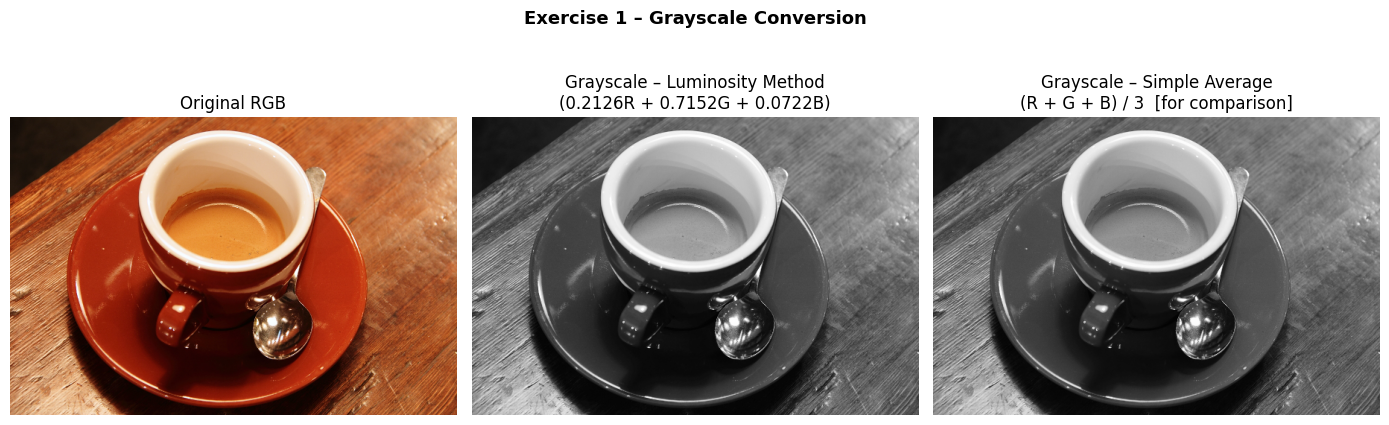

Luminosity grayscale – value range: 0 - 254


In [9]:
# ── Exercise 1: Luminosity-based Grayscale ────────────────────────────────────

def rgb_to_grayscale_luminosity(img: np.ndarray) -> np.ndarray:
    """
    Convert an RGB image to grayscale using the ITU-R BT.709 luminosity weights.

    Parameters
    ----------
    img : np.ndarray  shape (H, W, 3), dtype uint8

    Returns
    -------
    gray : np.ndarray  shape (H, W), dtype uint8
    """
    img_float = img.astype(np.float64)
    R, G, B   = img_float[:, :, 0], img_float[:, :, 1], img_float[:, :, 2]

    # Luminosity weights (ITU-R BT.709)
    gray = 0.2126 * R + 0.7152 * G + 0.0722 * B
    return np.clip(gray, 0, 255).astype(np.uint8)


gray_luminosity = rgb_to_grayscale_luminosity(color_img)

# ── Comparison: luminosity vs. simple average ─────────────────────────────────
gray_average = color_img.mean(axis=2).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(color_img)
axes[0].set_title('Original RGB')
axes[0].axis('off')

axes[1].imshow(gray_luminosity, cmap='gray')
axes[1].set_title('Grayscale – Luminosity Method\n(0.2126R + 0.7152G + 0.0722B)')
axes[1].axis('off')

axes[2].imshow(gray_average, cmap='gray')
axes[2].set_title('Grayscale – Simple Average\n(R + G + B) / 3  [for comparison]')
axes[2].axis('off')

plt.suptitle('Exercise 1 – Grayscale Conversion', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Luminosity grayscale – value range:",
      gray_luminosity.min(), "-", gray_luminosity.max())

---
## Exercise 2 – Dynamic Brightness Adjustment with a Slider

An interactive widget lets you drag a slider to brighten or darken the image in real time.  
The slider range is **−100 → +100** pixel units; pixel values are clamped to `[0, 255]`.

In [10]:
# ── Exercise 2: Dynamic Brightness with ipywidgets ───────────────────────────

def adjust_brightness(img: np.ndarray, delta: int) -> np.ndarray:
    """
    Adjust the brightness of an RGB image by adding `delta` to every pixel.

    Parameters
    ----------
    img   : np.ndarray  shape (H, W, 3), dtype uint8
    delta : int         value in [-255, 255]

    Returns
    -------
    np.ndarray  shape (H, W, 3), dtype uint8  – values clamped to [0, 255]
    """
    img_float = img.astype(np.int16)        # use int16 to avoid wrap-around
    adjusted  = img_float + delta
    return np.clip(adjusted, 0, 255).astype(np.uint8)


# ── Widget ────────────────────────────────────────────────────────────────────
slider = widgets.IntSlider(
    value=0, min=-100, max=100, step=1,
    description='Δ Brightness',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px')
)

output = widgets.Output()

def on_slider_change(change):
    delta = change['new']
    bright_img = adjust_brightness(color_img, delta)

    with output:
        output.clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))

        axes[0].imshow(color_img)
        axes[0].set_title('Original')
        axes[0].axis('off')

        sign   = '+' if delta >= 0 else ''
        axes[1].imshow(bright_img)
        axes[1].set_title(f'Brightness Adjusted  (Δ = {sign}{delta})')
        axes[1].axis('off')

        plt.suptitle('Exercise 2 – Dynamic Brightness Adjustment',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()

# Register callback and show initial frame
slider.observe(on_slider_change, names='value')
on_slider_change({'new': 0})

print("Drag the slider to adjust brightness interactively:")
display(slider, output)

Drag the slider to adjust brightness interactively:


IntSlider(value=0, description='Δ Brightness', layout=Layout(width='500px'), min=-100, style=SliderStyle(descr…

Output()

---
## Exercise 3 – Histogram Equalization on Each RGB Channel Separately

Histogram equalization redistributes pixel intensities so that each intensity value is used as uniformly as possible, improving global contrast.

Here we apply it **independently** to each channel (R, G, B) and then recombine them.

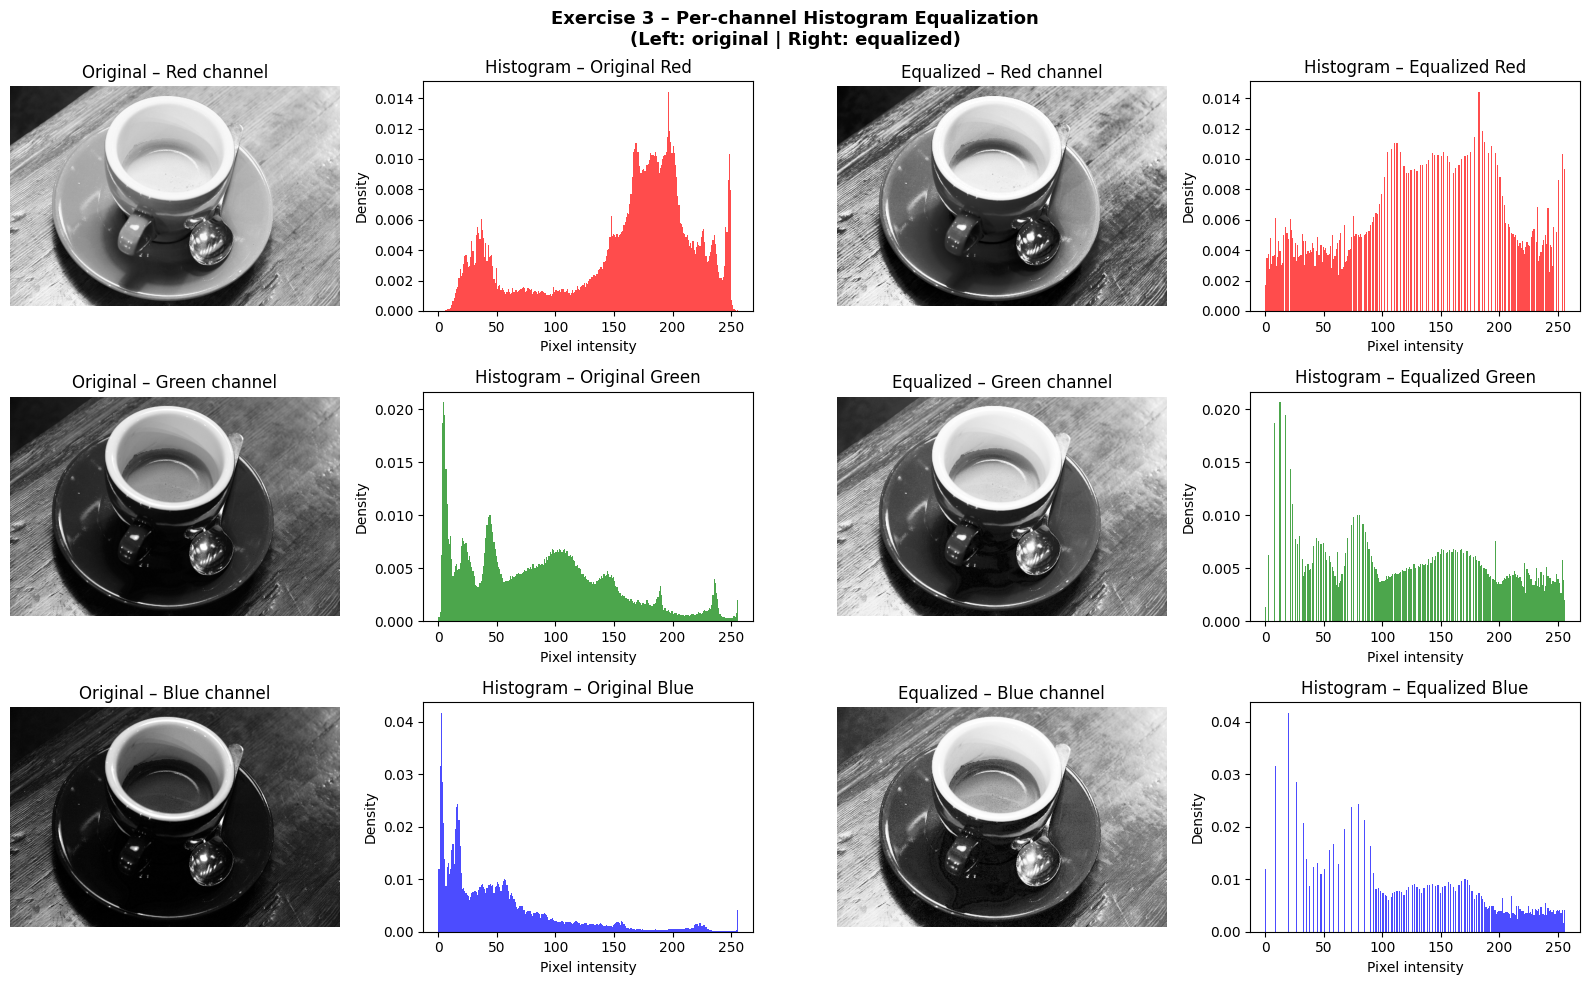

In [11]:
# ── Exercise 3: Per-channel Histogram Equalization ───────────────────────────

def equalize_channel(channel: np.ndarray) -> np.ndarray:
    """
    Perform histogram equalization on a single 2-D grayscale/channel array.

    Parameters
    ----------
    channel : np.ndarray  shape (H, W), dtype uint8

    Returns
    -------
    np.ndarray  shape (H, W), dtype uint8
    """
    # 1. Compute histogram (256 bins)
    hist, _ = np.histogram(channel.flatten(), bins=256, range=(0, 256))

    # 2. Cumulative distribution function (CDF)
    cdf = hist.cumsum()

    # 3. Mask zero-valued bins (avoid division by zero)
    cdf_min    = cdf[cdf > 0].min()
    total_pix  = channel.size

    # 4. Equalization mapping
    lut = np.round(
        (cdf - cdf_min) / (total_pix - cdf_min) * 255
    ).astype(np.uint8)

    return lut[channel]


def equalize_rgb(img: np.ndarray) -> np.ndarray:
    """
    Apply histogram equalization independently to each RGB channel.

    Parameters
    ----------
    img : np.ndarray  shape (H, W, 3), dtype uint8

    Returns
    -------
    np.ndarray  shape (H, W, 3), dtype uint8
    """
    R_eq = equalize_channel(img[:, :, 0])
    G_eq = equalize_channel(img[:, :, 1])
    B_eq = equalize_channel(img[:, :, 2])
    return np.stack([R_eq, G_eq, B_eq], axis=2)


eq_img = equalize_rgb(color_img)

# ── Plot: original vs equalised + per-channel histograms ─────────────────────
channel_names  = ['Red', 'Green', 'Blue']
channel_colors = ['red', 'green', 'blue']

fig, axes = plt.subplots(3, 4, figsize=(16, 10))

for row, (name, color) in enumerate(zip(channel_names, channel_colors)):
    orig_ch = color_img[:, :, row]
    eq_ch   = eq_img[:, :, row]

    # Column 0: original channel
    axes[row, 0].imshow(orig_ch, cmap='gray')
    axes[row, 0].set_title(f'Original – {name} channel')
    axes[row, 0].axis('off')

    # Column 1: original histogram
    axes[row, 1].hist(orig_ch.flatten(), bins=256, range=(0, 256),
                      color=color, alpha=0.7, density=True)
    axes[row, 1].set_title(f'Histogram – Original {name}')
    axes[row, 1].set_xlabel('Pixel intensity')
    axes[row, 1].set_ylabel('Density')

    # Column 2: equalized channel
    axes[row, 2].imshow(eq_ch, cmap='gray')
    axes[row, 2].set_title(f'Equalized – {name} channel')
    axes[row, 2].axis('off')

    # Column 3: equalized histogram
    axes[row, 3].hist(eq_ch.flatten(), bins=256, range=(0, 256),
                      color=color, alpha=0.7, density=True)
    axes[row, 3].set_title(f'Histogram – Equalized {name}')
    axes[row, 3].set_xlabel('Pixel intensity')
    axes[row, 3].set_ylabel('Density')

plt.suptitle(
    'Exercise 3 – Per-channel Histogram Equalization\n'
    '(Left: original | Right: equalized)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

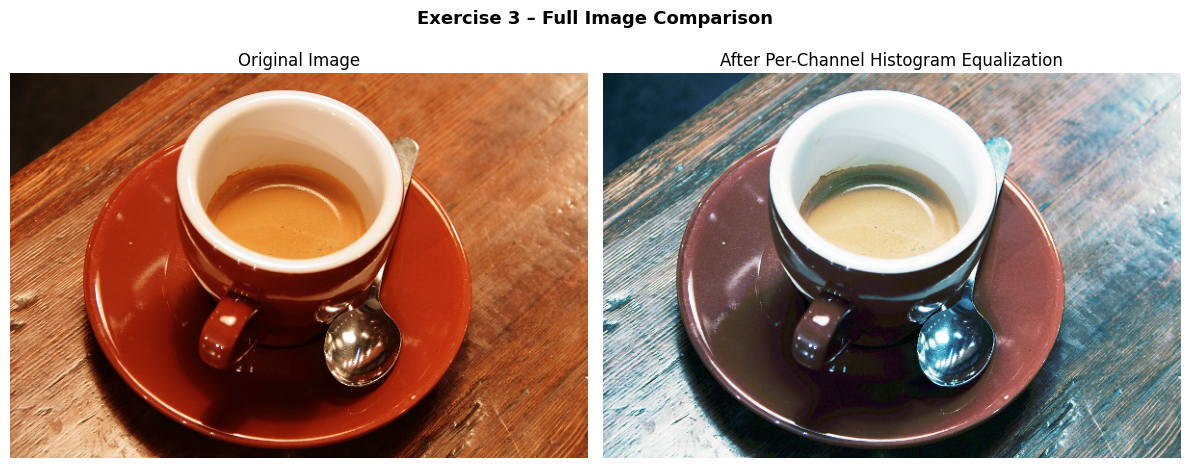

In [12]:
# ── Final side-by-side comparison of full images ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(color_img)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(eq_img)
axes[1].set_title('After Per-Channel Histogram Equalization')
axes[1].axis('off')

plt.suptitle('Exercise 3 – Full Image Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()